In [1]:
import h5py
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from spikeparam.patch.window import find_spike_times, window_spike
from spikeparam.patch.fit import PolySpikeGroup
from spikeparam.skg.fit import SKG, sim_gaussian_spike

# Skewed Gaussian Models

The spikes in pvc-6 can be fit with highly accurately (r^2=0.999) as the sum of two skewed Gaussians.

In [2]:
# Load data
file = h5py.File('../../datasets/pvc-6/153098.04.02_data.h5', 'r')
fs = 200000 

spikes = []

for i in range(20):

    # Read
    dset = file['Sweep_' + str(i)]
    sig = dset[:, 1]
    
    # Window spikes
    window_length = (2., 4.)
    thresh_amp = -10
    thresh_ms = 1.0
    
    spike_inds,  _= find_spike_times(sig, thresh_amp, thresh_ms)
    
    pad = int(sum(window_length) * fs / 1000) + 1
    pad = pad // 5
    
    starts = spike_inds - pad//2
    ends = spike_inds + pad//2
    
    for ind in range(len(spike_inds)):
       spike_inds[ind] = starts[ind] + np.argmax(sig[starts[ind]:ends[ind]])
    
    spike_inds = np.unique(spike_inds)
    
    if len(spike_inds) == 0:
        continue
        
    spikes.append(
        window_spike(sig, fs, spike_inds, window_length=window_length)
    )

spikes = np.vstack(spikes)

In [3]:
p0 = (
    .25, 0.15, 1.5, 1.5,
    .5,  0.15, -2.0, 0.1,
    40., -55.
)
skg = SKG(p0=p0)
skg.fit(spikes, progress=tqdm)

  0%|          | 0/99 [00:00<?, ?it/s]

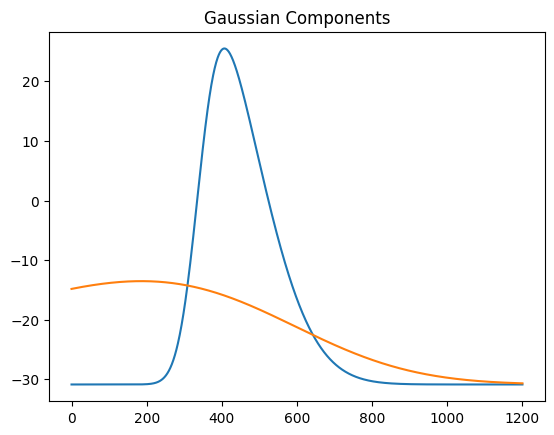

In [5]:
# Plot the model componets
xs = np.arange(len(spikes[0]))
g0, g1 = sim_gaussian_spike(xs, *skg.params_[0], return_separate=True)
plt.title("Gaussian Components")
plt.plot(g0)
plt.plot(g1);

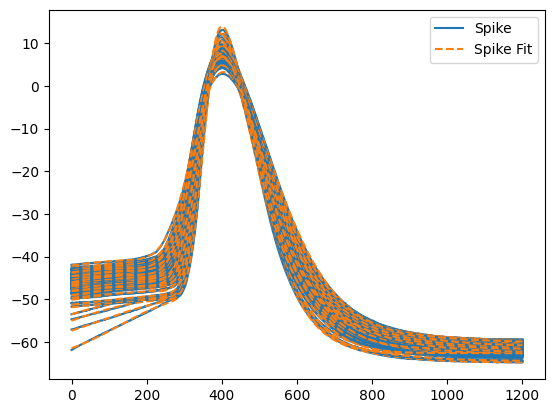

In [6]:
spikes_fit = np.zeros_like(spikes)
rsq = np.zeros(len(spikes))

for i in range(len(spikes)):
    spikes_fit[i] = sim_gaussian_spike(xs, *skg.params_[i])
    rsq[i] = np.corrcoef(spikes[i], spikes_fit[i])[0][1]

    l0 = "Spike" if i == 0 else ""
    l1 = "Spike Fit" if i == 0 else ""

    plt.plot(spikes[i], color='C0', label=l0)
    plt.plot(spikes_fit[i], ls='--', color='C1', label=l1)
plt.legend()

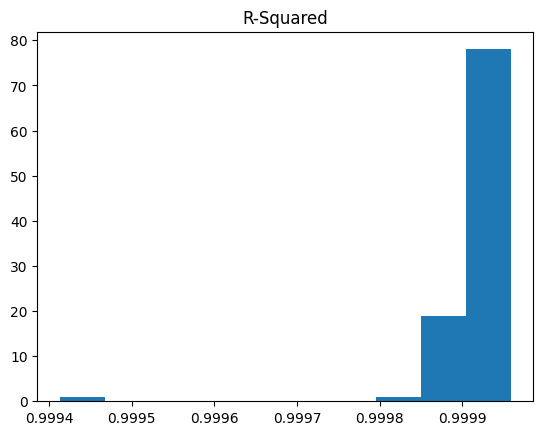

In [8]:
plt.title("R-Squared")
plt.hist(rsq);